In [1]:
import pystac_client
import xarray as xr
import esgvoc.api as ev

### Search using ESGF East Index 

In [2]:
stac_endpoint = "https://discovery.east.esgf.io"

In [3]:
clnt = pystac_client.Client.open(stac_endpoint)

### Check top-levels collections for CMIP6 present

In [4]:
collection_name = None

for coll in clnt.get_collections():
    print(f"{coll.id}: {coll.description}")
    if coll.id.upper() == "CMIP6":
        collection_name = coll.id

print(f"Using collection: {collection_name}") 

CMIP6: CMIP6 (Coupled Model Intercomparison Project Phase 6) is an international framework that coordinates global climate model simulations. It is used to understand past, present, and future climate changes and to support climate research and assessments such as IPCC reports.
CMIP6Plus: Data Reference Syntax (DRS) specifications for the Coupled Model Intercomparison Project Phase 6 Plus (CMIP6Plus)
CMIP7: Data Reference Syntax (DRS) specifications for the Coupled Model Intercomparison Project Phase 7 (CMIP7)
CORDEX-CMIP6: Data Reference Syntax (DRS) specifications for Coordinated Regional Climate Downscaling Experiment (CORDEX) based on the Coupled Model Intercomparison Project Phase 6 (CMIP6)
obs4REF: Data Reference Syntax (DRS) specifications for the obs4REF project
Using collection: CMIP6


### Search based on ScenarioMIP which has been indexed with Virtualizarr references

In [5]:
print(f"Searching in collection: {collection_name}")
item_search = clnt.search(
    collections=["CMIP6"],
    query=[
        #"cmip6:activity_id=ScenarioMIP",
        "cmip6:institution_id=MOHC",
        #"cmip6:variant_label=r1i1p1f1",
        #"cmip6:frequency=day",
        "cmip6:variable_id=tas"
    ],
    max_items=200,
)
print(f"Number of items found: {item_search.matched()}")

Searching in collection: CMIP6
Number of items found: 12158


In [6]:
items = list(item_search.items())

### Pick the first search hit, extract the Kerchunk reference if available, otherwise select a netCDF file. Load in xarray

In [7]:
file_ref = None

for item in items:
    if "reference_file" in item.assets:
        # Check for a Kerchunk reference file asset
        file_ref = item.assets["reference_file"]
        print(f"Found Kerchunk reference file: {file_ref.href}")
        break

if file_ref is not None:
    # Kerchunk reference file found, extract the open_zarr_kwargs and href
    zarr_kwargs = file_ref.to_dict()["open_zarr_kwargs"]
    file_uri = file_ref.href
else:  
    file_uri = items[0].assets[next(iter(items[0].assets))].href

print(f"Using file URI: {file_uri}")


Using file URI: https://dap.ceda.ac.uk/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-1-LL/ssp370/r1i1p1f2/Amon/tas/gn/v20220512/tas_Amon_UKESM1-1-LL_ssp370_r1i1p1f2_gn_201501-204912.nc


In [9]:
if file_ref is not None:
    kwargs = {
        "engine": "kerchunk",
        "open_dataset_options": {"chunks": {}}
    }
else:
    kwargs = {
        "engine": "h5netcdf"
    }

print(f"Opening dataset with kwargs: {kwargs}")
print(file_uri)
ds = xr.open_dataset(file_uri, **kwargs)


Opening dataset with kwargs: {'engine': 'h5netcdf'}
https://dap.ceda.ac.uk/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-1-LL/ssp370/r1i1p1f2/Amon/tas/gn/v20220512/tas_Amon_UKESM1-1-LL_ssp370_r1i1p1f2_gn_201501-204912.nc


In [10]:
ds

<xarray.Dataset> Size: 46MB
Dimensions:    (time: 420, bnds: 2, lat: 144, lon: 192)
Coordinates:
  * time       (time) object 3kB 2015-01-16 00:00:00 ... 2049-12-16 00:00:00
  * lat        (lat) float64 1kB -89.38 -88.12 -86.88 ... 86.88 88.12 89.38
  * lon        (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 7kB ...
    lat_bnds   (lat, bnds) float64 2kB ...
    lon_bnds   (lon, bnds) float64 3kB ...
    tas        (time, lat, lon) float32 46MB ...
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            ScenarioMIP AerChemMIP
    branch_method:          standard
    branch_time_in_child:   59400.0
    branch_time_in_parent:  0.0
    creation_date:          2022-05-12T15:07:25Z
    ...                     ...
    variable_id:            tas
    variable_name:          tas
    variant_label:          r1i1p1f2
    license:                CMIP6 model data produced by the Met Office Hadle...
    cmor_version:           3.6.1
    tracking_id:            hdl:21.14100/7b170260-67ac-47f2-9b75-736b1974dddb

### Plot first time step

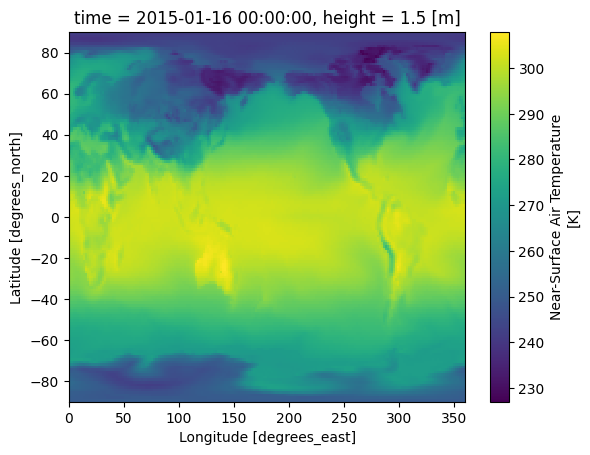

In [11]:
#ds.sel(time='2015-01').isel(time=0).tas.plot()
ds.isel(time=0).tas.plot()